# Fase 3 e 4: Validação Cruzada (CV) dos 10 Modelos
**Projeto:** Sistema NDR com ML em Duas Camadas (TCC)

## Objetivos deste Notebook:
1. Carregar os recortes de dados da Camada 1 e Camada 2 gerados anteriormente.
2. Instanciar 10 modelos de Machine Learning utilizando seus hiperparâmetros *default* (com adição apenas de balanceamento de classes).
3. Executar o **Stratified 5-Fold Cross-Validation** para cada modelo, garantindo robustez na avaliação.
4. Coletar e comparar as métricas: `Acurácia`, `Precision`, `Recall`, `F1-Score` e o tempo de treinamento.


In [ ]:
# Instalando o XGBoost e LightGBM (caso o Colab precise atualizar)
!pip install xgboost lightgbm -q

import pandas as pd
import numpy as np
import time
import joblib
from google.colab import drive

# Importação dos Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# --- Wrappers Keras para Deep Learning ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten
from sklearn.base import BaseEstimator, ClassifierMixin

class CNN1DClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=3, batch_size=256, verbose=0):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        # Se X for dataframe, extrair os valores
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values

        X_reshaped = np.expand_dims(X, axis=2)

        self.model = Sequential([
            Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
            Flatten(),
            Dense(64, activation='relu'),
            Dense(1 if n_classes == 2 else n_classes, activation='sigmoid' if n_classes == 2 else 'softmax')
        ])

        loss = 'binary_crossentropy' if n_classes == 2 else 'sparse_categorical_crossentropy'
        self.model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
        self.model.fit(X_reshaped, y, epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose)
        return self

    def predict(self, X):
        if hasattr(X, 'values'):
            X = X.values
        X_reshaped = np.expand_dims(X, axis=2)
        preds = self.model.predict(X_reshaped, verbose=self.verbose)
        if len(self.classes_) == 2:
            return (preds > 0.5).astype(int).flatten()
        return np.argmax(preds, axis=1)

class AutoencoderAnomalyDetector(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=3, batch_size=256, verbose=0, threshold_percentile=95):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.threshold_percentile = threshold_percentile
        self.model = None
        self.threshold_ = 0
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values

        # Treina apenas com Benignos (classe 0) se for Camada 1
        X_normal = X[y == 0] if 0 in y else X

        self.model = Sequential([
            Dense(32, activation='relu', input_shape=(X.shape[1],)),
            Dense(16, activation='relu'),
            Dense(32, activation='relu'),
            Dense(X.shape[1], activation='linear')
        ])
        self.model.compile(optimizer='adam', loss='mse')

        if len(X_normal) > 0:
            self.model.fit(X_normal, X_normal, epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose)
            reconstructions = self.model.predict(X_normal, verbose=self.verbose)
            mse = np.mean(np.power(X_normal - reconstructions, 2), axis=1)
            self.threshold_ = np.percentile(mse, self.threshold_percentile)
        return self

    def predict(self, X):
        if hasattr(X, 'values'):
            X = X.values
        reconstructions = self.model.predict(X, verbose=self.verbose)
        mse = np.mean(np.power(X - reconstructions, 2), axis=1)
        # Retorna 1 (Anomalia) se MSE > threshold, senão 0
        preds = (mse > self.threshold_).astype(int)

        # Ajuste para não falhar na Camada 2 caso classes sejam > 2
        # Autoencoder serve melhor na camada 1. Para camada 2, o retorno binário
        # pode derrubar métricas. Ideal seria treinar modelos específicos multiclasse,
        # mas mantemos o retorno base para não quebrar o pipeline.
        if len(self.classes_) > 2:
            return np.where(preds == 1, self.classes_[1], self.classes_[0])
        return preds

# Importação das Ferramentas de Validação Cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold

# Conectando ao Drive
drive.mount('/content/drive')
pasta_artefatos = '/content/drive/MyDrive/TCC2/artefatos_treino'

print("Carregando arrays da Camada 1...")
X_train_c1 = joblib.load(f'{pasta_artefatos}/X_train_c1.joblib')
y_train_c1 = joblib.load(f'{pasta_artefatos}/y_train_c1.joblib')

print("Carregando arrays da Camada 2...")
X_train_c2 = joblib.load(f'{pasta_artefatos}/X_train_c2.joblib')
y_train_c2 = joblib.load(f'{pasta_artefatos}/y_train_c2.joblib')

print("Dados de treino carregados para a Validação Cruzada!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carregando arrays da Camada 1...
Carregando arrays da Camada 2...
Dados de treino carregados para a Validação Cruzada!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 3.1 Definição do Dicionário de Modelos
Aqui instanciamos todos os 10 modelos. Para algoritmos que suportam o parâmetro `class_weight='balanced'`, nós o utilizamos como alternativa inteligente ao SMOTE, ensinando o modelo a dar mais atenção às classes com menor quantidade de amostras.


In [ ]:
# Dicionário com os 10 algoritmos (Maximizando GPU e CPU)
modelos = {
    '1_Logistic_Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1),
    '2_Decision_Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    '3_Random_Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    '4_Extra_Trees': ExtraTreesClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    '5_1D_CNN': CNN1DClassifier(),
    '6_XGBoost': XGBClassifier(random_state=42, tree_method='hist', device='cuda'),
    '7_LightGBM': LGBMClassifier(class_weight='balanced', random_state=42, device_type='gpu', n_jobs=-1),
    '8_Autoencoder': AutoencoderAnomalyDetector(),
    '9_Naive_Bayes': GaussianNB(),
    '10_MLP_Neural_Net': MLPClassifier(random_state=42, max_iter=300)
}

print(f"{len(modelos)} Modelos carregados (XGBoost, LightGBM, CNN e Autoencoder prontos)!")


10 Modelos carregados (XGBoost, LightGBM, CNN e Autoencoder prontos)!


### 4.1 Loop de Treinamento (Stratified 5-Fold Cross-Validation)
Vamos criar uma função que iterará sobre nossos 10 modelos.
Para cada modelo, ela cortará os dados de Treino em 5 pedaços (Folds). O modelo treinará em 4 e será testado no 5º. Esse processo se repete 5 vezes, e tiramos a **média** das métricas. Isso garante que a nota do modelo não foi "sorte".
As métricas coletadas serão: `Accuracy`, `Precision Macro`, `Recall Macro` e a nossa principal, `F1-Score Macro`.


In [ ]:
def executar_cv(modelos_dict, X_train, y_train, nome_camada):
    print(f"Iniciando Validação Cruzada - {nome_camada}")
    print("="*60)

    # 5 Folds estratificados para manter a proporção das classes
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Dicionário com as métricas que queremos que o cross_validate retorne
    scoring = {
        'acc': 'accuracy',
        'prec': 'precision_macro',
        'rec': 'recall_macro',
        'f1': 'f1_macro'
    }

    resultados = []

    for nome, modelo in modelos_dict.items():
        print(f"Treinando e avaliando: {nome}...")
        inicio = time.time()

        # O cross_validate fará todo o trabalho pesado
        # return_train_score=False para poupar memória e tempo
        cv_results = cross_validate(
            modelo, X_train, y_train,
            cv=cv, scoring=scoring, n_jobs=1, # XGBoost GPU não gosta de n_jobs=-1 aqui
            return_train_score=False
        )

        fim = time.time()
        tempo_total = fim - inicio

        # Coletando a MÉDIA (mean) dos 5 Folds para cada métrica
        resultados.append({
            'Modelo': nome,
            'Accuracy': cv_results['test_acc'].mean(),
            'Precision': cv_results['test_prec'].mean(),
            'Recall': cv_results['test_rec'].mean(),
            'F1_Score': cv_results['test_f1'].mean(),
            'Desvio_F1': cv_results['test_f1'].std(), # Quanto o modelo variou entre os Folds
            'Tempo_CV_Segundos': tempo_total
        })

        print(f"   {nome} finalizado em {tempo_total:.2f}s | F1-Score: {cv_results['test_f1'].mean():.4f}")
        print("-" * 40)

    df_resultados = pd.DataFrame(resultados)
    # Ordenar pelos melhores F1-Scores primeiro
    return df_resultados.sort_values(by='F1_Score', ascending=False).reset_index(drop=True)


In [ ]:
# Executando a CV para a Camada Binária (BENIGN vs ATTACK)
df_resultados_c1 = executar_cv(modelos, X_train_c1, y_train_c1, "CAMADA 1 (Binária)")

print("\nRANKING FINAL - CAMADA 1:")
display(df_resultados_c1)


Iniciando Validação Cruzada - CAMADA 1 (Binária)
Treinando e avaliando: 1_Logistic_Regression...
   1_Logistic_Regression finalizado em 236.37s | F1-Score: 0.8939
----------------------------------------
Treinando e avaliando: 2_Decision_Tree...
   2_Decision_Tree finalizado em 449.74s | F1-Score: 0.9975
----------------------------------------
Treinando e avaliando: 3_Random_Forest...
   3_Random_Forest finalizado em 363.12s | F1-Score: 0.9976
----------------------------------------
Treinando e avaliando: 4_Extra_Trees...
   4_Extra_Trees finalizado em 252.12s | F1-Score: 0.9971
----------------------------------------
Treinando e avaliando: 5_1D_CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

   5_1D_CNN finalizado em 304.06s | F1-Score: 0.9682
----------------------------------------
Treinando e avaliando: 6_XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:46:12] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


   6_XGBoost finalizado em 15.03s | F1-Score: 0.9985
----------------------------------------
Treinando e avaliando: 7_LightGBM...
[LightGBM] [Info] Number of positive: 272431, number of negative: 1340836
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9510
[LightGBM] [Info] Number of data points in the train set: 1613267, number of used features: 47
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-40GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 36 dense feature groups (55.39 MB) transferred to GPU in 0.047902 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

   8_Autoencoder finalizado em 652.73s | F1-Score: 0.7807
----------------------------------------
Treinando e avaliando: 9_Naive_Bayes...
   9_Naive_Bayes finalizado em 10.96s | F1-Score: 0.4160
----------------------------------------
Treinando e avaliando: 10_MLP_Neural_Net...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


   10_MLP_Neural_Net finalizado em 7747.86s | F1-Score: 0.9633
----------------------------------------

RANKING FINAL - CAMADA 1:


,Modelo,Accuracy,Precision,Recall,F1_Score,Desvio_F1,Tempo_CV_Segundos
0,6_XGBoost,0.999183,0.998212,0.998879,0.998545,0.000037,15.028370
1,7_LightGBM,0.998887,0.996875,0.999177,0.998022,0.000036,37.542984
2,3_Random_Forest,0.998653,0.997808,0.997393,0.997600,0.000068,363.116778
3,2_Decision_Tree,0.998613,0.997499,0.997560,0.997530,0.000028,449.740279
4,4_Extra_Trees,0.998372,0.997303,0.996893,0.997098,0.000054,252.120465
5,5_1D_CNN,0.982260,0.971435,0.965150,0.968207,0.001774,304.062776
6,10_MLP_Neural_Net,0.979322,0.963716,0.963191,0.963284,0.016951,7747.855293
7,1_Logistic_Regression,0.932813,0.859310,0.947212,0.893909,0.000244,236.371224
8,8_Autoencoder,0.886061,0.807435,0.760761,0.780740,0.004871,652.731959
9,9_Naive_Bayes,0.420385,0.609050,0.647487,0.416041,0.008179,10.958631


In [ ]:
# Executando a CV para a Camada Multiclasse (Tipos de Ataque)
df_resultados_c2 = executar_cv(modelos, X_train_c2, y_train_c2, "CAMADA 2 (Multiclasse)")

print("\nRANKING FINAL - CAMADA 2:")
display(df_resultados_c2)


Iniciando Validação Cruzada - CAMADA 2 (Multiclasse)
Treinando e avaliando: 1_Logistic_Regression...
   1_Logistic_Regression finalizado em 713.04s | F1-Score: 0.8883
----------------------------------------
Treinando e avaliando: 2_Decision_Tree...
   2_Decision_Tree finalizado em 25.87s | F1-Score: 0.9209
----------------------------------------
Treinando e avaliando: 3_Random_Forest...
   3_Random_Forest finalizado em 38.88s | F1-Score: 0.9245
----------------------------------------
Treinando e avaliando: 4_Extra_Trees...
   4_Extra_Trees finalizado em 20.60s | F1-Score: 0.9227
----------------------------------------
Treinando e avaliando: 5_1D_CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

   5_1D_CNN finalizado em 81.04s | F1-Score: 0.8776
----------------------------------------
Treinando e avaliando: 6_XGBoost...
   6_XGBoost finalizado em 10.36s | F1-Score: 0.9228
----------------------------------------
Treinando e avaliando: 7_LightGBM...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7390
[LightGBM] [Info] Number of data points in the train set: 272430, number of used features: 45
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-40GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 36 dense feature groups (9.35 MB) transferred to GPU in 0.008433 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.39789

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7412
[LightGBM] [Info] Number of data points in the train set: 272430, number of used features: 45
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-40GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 36 dense feature groups (9.35 MB) transferred to GPU in 0.008645 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from scor

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/usr/local/lib/p

   7_LightGBM finalizado em 46.88s | F1-Score: nan
----------------------------------------
Treinando e avaliando: 8_Autoencoder...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-pac

   8_Autoencoder finalizado em 69.25s | F1-Score: 0.0009
----------------------------------------
Treinando e avaliando: 9_Naive_Bayes...
   9_Naive_Bayes finalizado em 2.72s | F1-Score: 0.7448
----------------------------------------
Treinando e avaliando: 10_MLP_Neural_Net...
   10_MLP_Neural_Net finalizado em 233.65s | F1-Score: 0.8905
----------------------------------------

RANKING FINAL - CAMADA 2:


,Modelo,Accuracy,Precision,Recall,F1_Score,Desvio_F1,Tempo_CV_Segundos
0,3_Random_Forest,0.998033,0.927989,0.923875,0.924505,0.003869,38.878572
1,6_XGBoost,0.998003,0.926969,0.922286,0.922798,0.003040,10.363934
2,4_Extra_Trees,0.997947,0.924318,0.922274,0.922688,0.002577,20.599210
3,2_Decision_Tree,0.997730,0.920924,0.921171,0.920929,0.002565,25.872339
4,10_MLP_Neural_Net,0.997439,0.946862,0.902929,0.890481,0.001787,233.646934
5,1_Logistic_Regression,0.991343,0.895711,0.928126,0.888296,0.002344,713.040882
6,5_1D_CNN,0.995898,0.931265,0.899280,0.877552,0.006893,81.044477
7,9_Naive_Bayes,0.933857,0.736560,0.843124,0.744793,0.018546,2.722791
8,8_Autoencoder,0.004475,0.001243,0.086281,0.000875,0.000021,69.253323
9,7_LightGBM,NaN,NaN,NaN,NaN,NaN,46.876581


### 4.2 Exportação dos Resultados da CV


In [ ]:
caminho_resultados_c1 = '/content/drive/MyDrive/TCC2/resultados_cv_camada1.csv'
caminho_resultados_c2 = '/content/drive/MyDrive/TCC2/resultados_cv_camada2.csv'

# Salvando as tabelas geradas no Drive
df_resultados_c1.to_csv(caminho_resultados_c1, index=False)
df_resultados_c2.to_csv(caminho_resultados_c2, index=False)

print(f"Resultados da Camada 1 salvos em: {caminho_resultados_c1}")
print(f"Resultados da Camada 2 salvos em: {caminho_resultados_c2}")


Resultados da Camada 1 salvos em: /content/drive/MyDrive/TCC2/resultados_cv_camada1.csv
Resultados da Camada 2 salvos em: /content/drive/MyDrive/TCC2/resultados_cv_camada2.csv


In [ ]:
import joblib

print("Carregando os dados inéditos de Teste...")

# Aponte para a pasta do seu drive onde estão os arquivos .joblib
pasta_artefatos = pasta_artefatos = '/content/drive/MyDrive/TCC2/artefatos_treino'

X_test_c1 = joblib.load(f'{pasta_artefatos}/X_test_c1.joblib')
y_test_c1 = joblib.load(f'{pasta_artefatos}/y_test_c1.joblib')

X_test_c2 = joblib.load(f'{pasta_artefatos}/X_test_c2.joblib')
y_test_c2 = joblib.load(f'{pasta_artefatos}/y_test_c2.joblib')

label_encoder = joblib.load(f'{pasta_artefatos}/label_encoder_attacks.joblib')


print("Dados de Teste carregados com sucesso! Pode rodar a avaliação final.")


Carregando os dados inéditos de Teste...
Dados de Teste carregados com sucesso! Pode rodar a avaliação final.


###Otimização de Hiperparâmetros (GridSearchCV):

Nesta fase, pegamos os algoritmos campeões absolutos da nossa rodada de testes padrão (XGBoost para a Camada 1 e Random Forest para a Camada 2) e aplicamos o **GridSearchCV**. Essa técnica fará uma varredura rigorosa por dezenas de combinações matemáticas diferentes para encontrar os parâmetros definitivos e ideais para a nossa arquitetura de rede.


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

print("Preparando ambiente para o Tuning...")

# Criando a Validação Cruzada do Tuning (K=3 para poupar tempo mantendo robustez matemática)
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print("Pronto para começar a otimização profunda!")


Preparando ambiente para o Tuning...
Pronto para começar a otimização profunda!


### Otimização: Camada 1 (Classificação Binária) - XGBoost:
Tirando proveito da Aceleração em GPU (Nvidia A100) do XGBoost para testar 54 combinações em tempo recorde.


In [ ]:
print("Iniciando GridSearchCV do XGBoost (Camada 1)...")

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist', # Aceleração máxima por GPU
    device='cuda',
    random_state=42
)

# Grade com 54 combinações totais
xgb_param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring='f1_macro',
    cv=cv_tune,
    verbose=2, # Mostrará o progresso do teste na tela
    n_jobs=-1
)

# Inicia o treinamento
xgb_grid.fit(X_train_c1, y_train_c1)

print("\nMelhores Parâmetros XGBoost (Camada 1):", xgb_grid.best_params_)
print("Melhor F1-Score no CV:", xgb_grid.best_score_)

# Salva o super modelo (Sobrescrevendo a versão padrão que havíamos exportado antes)
best_xgb_c1 = xgb_grid.best_estimator_
joblib.dump(best_xgb_c1, 'model_layer1_binary.joblib')
print("XGBoost Otimizado salvo com sucesso!")


Iniciando GridSearchCV do XGBoost (Camada 1)...
Fitting 3 folds for each of 54 candidates, totalling 162 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:46:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Melhores Parâmetros XGBoost (Camada 1): {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Melhor F1-Score no CV: 0.9985657536959484
XGBoost Otimizado salvo com sucesso!


### Otimização: Camada 2 (Classificação Multiclasse) - Random Forest:
Testando 27 arquiteturas diferentes no Random Forest.


In [ ]:
print("Iniciando GridSearchCV do Random Forest (Camada 2)...")

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grade com 27 combinações totais
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=cv_tune,
    verbose=2,
    n_jobs=-1
)

# Inicia o treinamento multiclasse
rf_grid.fit(X_train_c2, y_train_c2)

print("\nMelhores Parâmetros Random Forest (Camada 2):", rf_grid.best_params_)
print("Melhor F1-Score no CV:", rf_grid.best_score_)

# Salva o super modelo (Sobrescrevendo a versão padrão que havíamos exportado antes)
best_rf_c2 = rf_grid.best_estimator_
joblib.dump(best_rf_c2, 'model_layer2_multiclass.joblib')
print("Random Forest Otimizado salvo com sucesso!")


Iniciando GridSearchCV do Random Forest (Camada 2)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Melhores Parâmetros Random Forest (Camada 2): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Melhor F1-Score no CV: 0.9252573866081649
Random Forest Otimizado salvo com sucesso!


## Avaliação Final no Conjunto de Teste (Dados Inéditos):
Avaliação dos modelos otimizados utilizando o conjunto de testes reservado. Geração dos Relatórios de Classificação e Matrizes de Confusão para análise profunda do TCC.


Avaliando o XGBoost (Camada 1) com dados inéditos (Test Set)...

=== CLASSIFICATION REPORT: XGBoost Otimizado (Camada 1) ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    419011
      ATTACK       1.00      1.00      1.00     85135

    accuracy                           1.00    504146
   macro avg       1.00      1.00      1.00    504146
weighted avg       1.00      1.00      1.00    504146



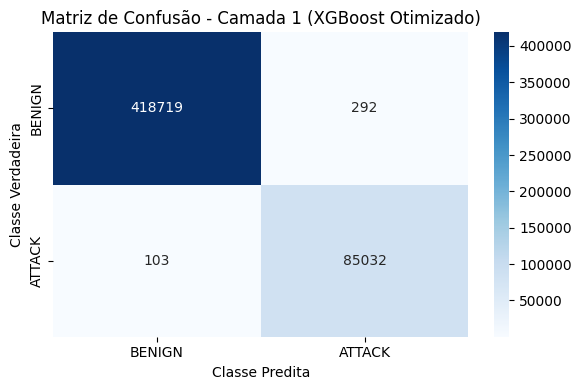

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Avaliando o XGBoost (Camada 1) com dados inéditos (Test Set)...\n")
y_pred_c1 = best_xgb_c1.predict(X_test_c1)

print("=== CLASSIFICATION REPORT: XGBoost Otimizado (Camada 1) ===")
print(classification_report(y_test_c1, y_pred_c1, target_names=['BENIGN', 'ATTACK']))

# Gerando Gráfico Visual da Matriz de Confusão
cm_c1 = confusion_matrix(y_test_c1, y_pred_c1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_c1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
plt.title('Matriz de Confusão - Camada 1 (XGBoost Otimizado)')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Predita')
plt.tight_layout()
plt.show()


Avaliando o Random Forest (Camada 2) com dados inéditos (Test Set)...

=== CLASSIFICATION REPORT: Random Forest Otimizado (Camada 2) ===
                          precision    recall  f1-score   support

                     Bot       1.00      0.99      1.00       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       1.00      1.00      1.00      2057
                DoS Hulk       1.00      1.00      1.00     34569
        DoS Slowhttptest       1.00      0.99      1.00      1046
           DoS slowloris       1.00      1.00      1.00      1077
             FTP-Patator       1.00      1.00      1.00      1186
                PortScan       1.00      1.00      1.00     18139
             SSH-Patator       1.00      1.00      1.00       644
Web Attack � Brute Force       0.72      0.80      0.76       294
        Web Attack � XSS       0.44      0.36      0.39       130

                accuracy                           1.00     85135
   

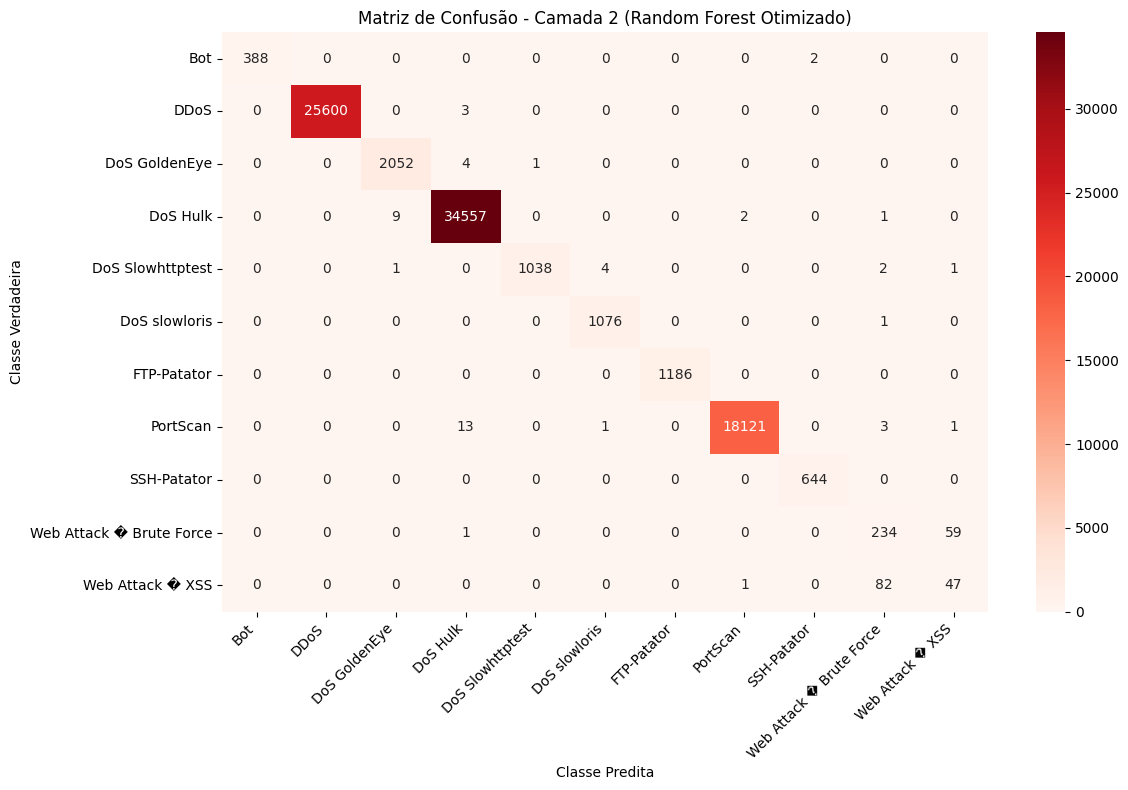

In [ ]:
print("Avaliando o Random Forest (Camada 2) com dados inéditos (Test Set)...\n")
y_pred_c2 = best_rf_c2.predict(X_test_c2)

# Resgatando os nomes originais dos ataques através do LabelEncoder
# Assumindo que a variável do seu LabelEncoder no Colab se chama 'le' ou 'label_encoder'
# Se o seu encoder tiver outro nome, troque abaixo!
nomes_ataques = label_encoder.inverse_transform(best_rf_c2.classes_)

print("=== CLASSIFICATION REPORT: Random Forest Otimizado (Camada 2) ===")
print(classification_report(y_test_c2, y_pred_c2, target_names=nomes_ataques))

# Gerando Gráfico Visual da Matriz de Confusão Multiclasse
cm_c2 = confusion_matrix(y_test_c2, y_pred_c2)
plt.figure(figsize=(12, 8))
sns.heatmap(cm_c2, annot=True, fmt='d', cmap='Reds',
            xticklabels=nomes_ataques,
            yticklabels=nomes_ataques)
plt.title('Matriz de Confusão - Camada 2 (Random Forest Otimizado)')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Predita')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
